In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor


In [14]:
day = pd.read_csv("day.csv")

In [15]:
day.drop(
    columns=["instant", "dteday", "yr", "casual", "registered"],
    inplace=True
)

day.drop_duplicates(inplace=True)
day.fillna(day.median(numeric_only=True), inplace=True)

In [16]:
day = day.sort_values(by=["mnth", "weekday"])

# Lag features
day["cnt_lag_1"] = day["cnt"].shift(1)
day["cnt_lag_7"] = day["cnt"].shift(7)

# Rolling features
day["cnt_roll_3"] = day["cnt"].rolling(3).mean()
day["cnt_roll_7"] = day["cnt"].rolling(7).mean()

# Remove NA rows created by lag/rolling
day.dropna(inplace=True)

In [17]:
X = day.drop("cnt", axis=1)
y = day["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2]
}

In [19]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


In [20]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="r2",
    verbose=1,
    n_jobs=-1
)


In [21]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.8, 0.9, 1.0]},
                   scoring='r2', verbose=1)

In [22]:
best_model = random_search.best_estimator_


In [23]:
y_pred = best_model.predict(X_test)

In [24]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nBest Parameters Found:")
print(random_search.best_params_)

print("\nModel Performance After Tuning:")
print("R2 Score :", r2)
print("RMSE     :", rmse)


Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}

Model Performance After Tuning:
R2 Score : 0.8215784442826041
RMSE     : 839.9651590381583


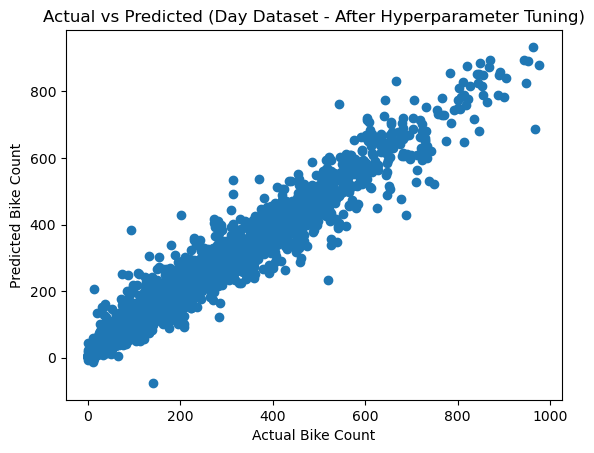

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")
plt.title("Actual vs Predicted (Day Dataset - After Hyperparameter Tuning)")
plt.show()

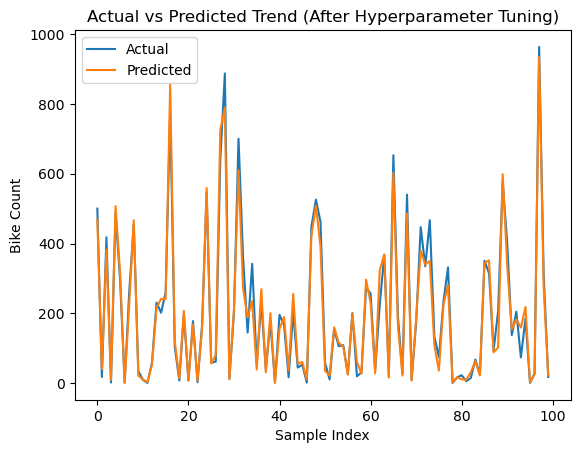

In [34]:
plt.figure()
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Bike Count")
plt.title("Actual vs Predicted Trend (After Hyperparameter Tuning)")
plt.legend()
plt.show()

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor

In [28]:
hour = pd.read_csv("hour.csv")

# Drop required columns
hour.drop(
    columns=["instant", "dteday", "yr", "casual", "registered"],
    inplace=True
)

# Remove duplicates
hour.drop_duplicates(inplace=True)

# Handle missing values
hour.fillna(hour.median(numeric_only=True), inplace=True)

In [29]:
# Sort data properly
hour = hour.sort_values(by=["mnth", "hr"])

# Lag features
hour["cnt_lag_1"] = hour["cnt"].shift(1)
hour["cnt_lag_24"] = hour["cnt"].shift(24)

# Rolling features
hour["cnt_roll_3"] = hour["cnt"].rolling(3).mean()
hour["cnt_roll_24"] = hour["cnt"].rolling(24).mean()

# Drop NaN rows created by lags
hour.dropna(inplace=True)

In [30]:
X = hour.drop("cnt", axis=1)
y = hour["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [5, 6, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,          # FAST
    cv=3,               # FAST
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [200, 300, 400],
                                        'subsample': [0.8, 0.9]},
                   scoring='r2', verbose=1)

In [32]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Best R2 Score:", r2)
print("RMSE:", rmse)
print("Best Parameters:", search.best_params_)

Best R2 Score: 0.9544427127979034
RMSE: 39.79843506948544
Best Parameters: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


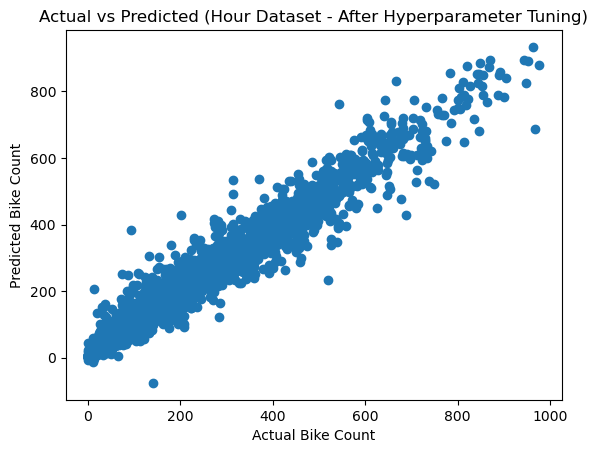

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")
plt.title("Actual vs Predicted (Hour Dataset - After Hyperparameter Tuning)")
plt.show()

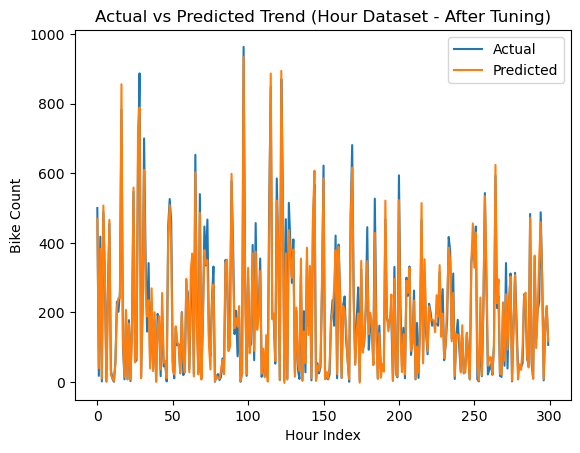

In [36]:
plt.figure()
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")
plt.xlabel("Hour Index")
plt.ylabel("Bike Count")
plt.title("Actual vs Predicted Trend (Hour Dataset - After Tuning)")
plt.legend()
plt.show()